In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Path to dataset files: /kaggle/input/hotel-booking-demand


In [5]:
import os

file_path = os.path.join(path, 'hotel_bookings.csv')
df = pd.read_csv(file_path)

In [6]:
print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [7]:
print('Dataset columns: ', df.columns)
print('Dataset shape: ', df.shape)
print('Data Types: ', df.dtypes )

Dataset columns:  Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')
Dataset shape:  (119390, 32)
Data Types:  hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
#B4 cleaning

In [10]:
miss_values=df.isnull().sum()
miss_percentage=(df.isnull().sum()/len(df))*100
missing_report=pd.DataFrame({'Missing_values ': miss_values,
                             'Missing_percentage':miss_percentage})

In [11]:
missing_report=missing_report[missing_report['Missing_values ']>0]

In [12]:
missing_report.sort_values('Missing_percentage',ascending=False)

,Missing_values,Missing_percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


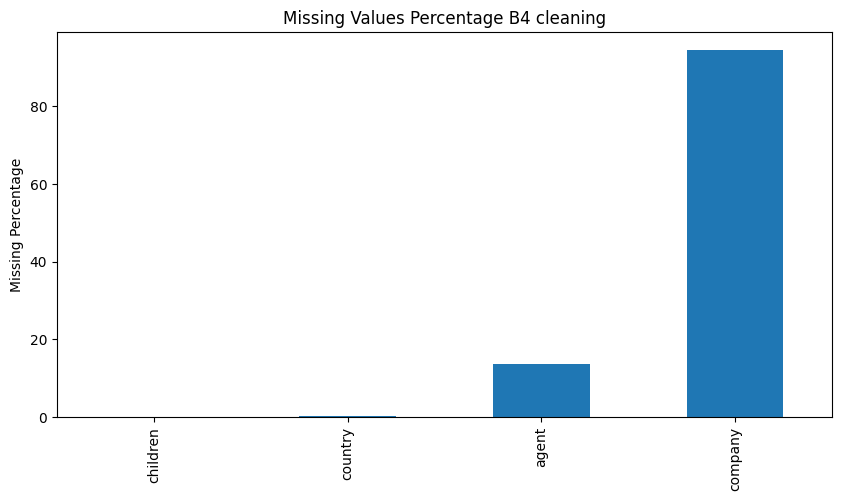

In [13]:
missing_report['Missing_percentage'].plot(kind='bar',figsize= (10,5))
plt.title("Missing Values Percentage B4 cleaning")
plt.ylabel("Missing Percentage")
plt.show()


In [14]:
dulpicate_rows=df.duplicated().sum()
print("No.of duplicate rows B4 cleaning",dulpicate_rows)


No.of duplicate rows B4 cleaning 31994


In [15]:
print(df.dtypes.value_counts())

int64      16
object     12
float64     4
Name: count, dtype: int64


In [16]:
df['meal'].value_counts()

,count
meal,
BB,92310
HB,14463
SC,10650
Undefined,1169
FB,798


In [17]:
df['market_segment'].value_counts()

,count
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2


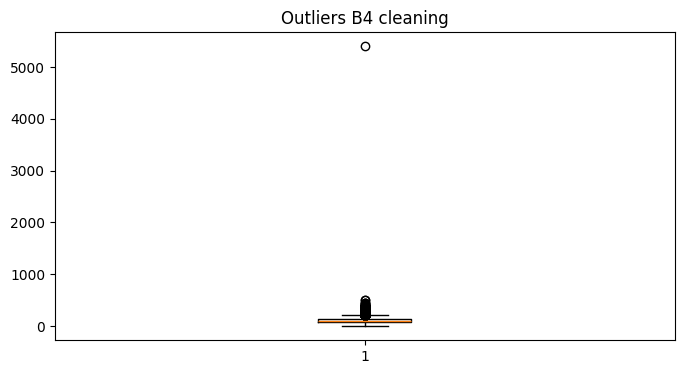

In [18]:
plt.figure(figsize=(8,4))
plt.boxplot(df['adr'])
plt.title("Outliers B4 cleaning")
plt.show()

In [19]:
zero_guest_rows=df[(df['adults']==0) & (df['children']==0) & (df['babies']==0)].shape[0]
print("No.of rows with zero guests",zero_guest_rows)

No.of rows with zero guests 180


In [20]:
clean_df=df.copy()

In [21]:
clean_df.drop('company',axis=1,inplace=True)

In [22]:
clean_df['agent'].fillna(0,inplace=True)

/tmp/ipykernel_10494/3296756788.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df['agent'].fillna(0,inplace=True)


In [23]:
clean_df['country'].fillna('Unknown',inplace=True)

/tmp/ipykernel_10494/641727478.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df['country'].fillna('Unknown',inplace=True)


In [24]:
clean_df['children'].fillna(clean_df['children'].median(),inplace=True)

/tmp/ipykernel_10494/4253871273.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df['children'].fillna(clean_df['children'].median(),inplace=True)


In [25]:
clean_df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [26]:
clean_df=clean_df.drop_duplicates()

In [27]:
print("New Shape:",clean_df.shape)
print("No.of duplicates after cleaning:",clean_df.duplicated().sum())

New Shape: (87389, 31)
No.of duplicates after cleaning: 0


In [28]:
clean_df=clean_df[~((clean_df['adults']==0) & (clean_df['children']==0) & (clean_df['babies']==0))]

In [29]:
print("Shape after removing invalid rows: ",clean_df.shape)

Shape after removing invalid rows:  (87223, 31)


In [30]:
Q1=clean_df['adr'].quantile(0.25)
Q3=clean_df['adr'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
clean_df=clean_df[(clean_df['adr']>=lower_bound) & (clean_df['adr']<=upper_bound)]
print("Shape after removing outliers: ",clean_df.shape)

Shape after removing outliers:  (84715, 31)


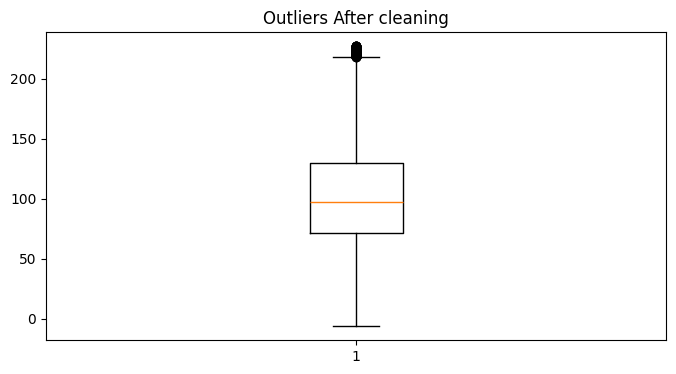

In [31]:
plt.figure(figsize=(8,4))
plt.boxplot(clean_df['adr'])
plt.title("Outliers After cleaning")
plt.show()

In [32]:
clean_df['total_guests']=clean_df['adults']+clean_df['children']+clean_df['babies']

In [33]:
clean_df['total_nights']=clean_df['stays_in_weekend_nights']+clean_df['stays_in_week_nights']

In [54]:
after_missing=clean_df.isnull().sum().sum()
after_duplicates=clean_df.duplicated().sum()
after_rows=clean_df.shape[0]
after_cols=clean_df.shape[1]


In [52]:
before_missing = df.isnull().sum().sum()
before_duplicates = df.duplicated().sum()
before_rows = df.shape[0]
before_cols = df.shape[1]

In [55]:
comparison = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Missing Values', 'Duplicate Rows'],
    'Before Cleaning': [before_rows, before_cols, before_missing, before_duplicates],
    'After Cleaning': [after_rows, after_cols, after_missing, after_duplicates]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Total Rows,119390,84715
1,Total Columns,32,34
2,Missing Values,129425,0
3,Duplicate Rows,31994,0


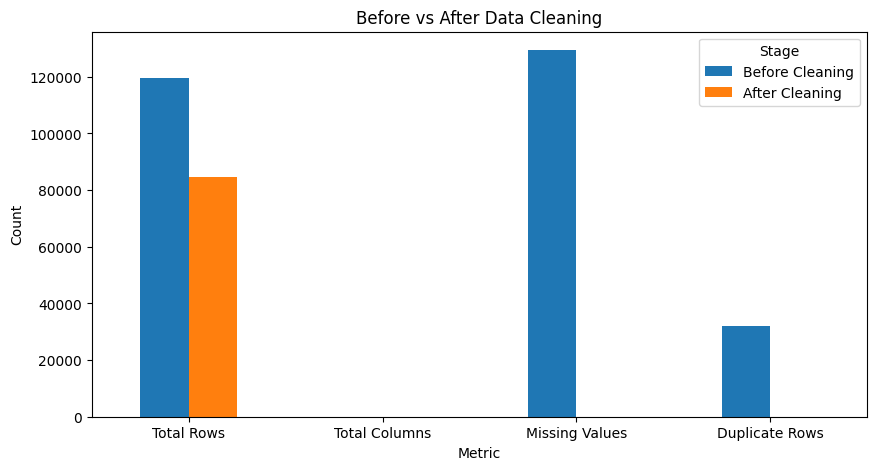

In [56]:
comparison.set_index('Metric').plot(kind='bar', figsize=(10,5))
plt.title("Before vs After Data Cleaning")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Stage")
plt.show()

In [57]:
clean_df.to_csv('hotel_bookings_cleaned.csv',index=False)

Removed missing values using appropriate strategies

Dropped highly incomplete column (company)

Eliminated 31,994 duplicate records

Removed invalid bookings (zero guests)

Handled outliers in ADR using IQR method

Engineered new features:
total_guests
total_nights
arrival_month_num
is_family

**Final dataset is clean and ready for analysis or machine learning**